In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [6]:
data = pd.read_csv('smart_home_energy_consumption_large.csv')

In [7]:
data.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Time,Date,Outdoor Temperature (°C),Season,Household Size
0,94,Fridge,0.20,21:12,2023-12-02,-1.0,Fall,2
1,435,Oven,0.23,20:11,2023-08-06,31.1,Summer,5
2,466,Dishwasher,0.32,06:39,2023-11-21,21.3,Fall,3
3,496,Heater,3.92,21:56,2023-01-21,-4.2,Winter,1
4,137,Microwave,0.44,04:31,2023-08-26,34.5,Summer,5


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Home ID                   100000 non-null  int64  
 1   Appliance Type            100000 non-null  object 
 2   Energy Consumption (kWh)  100000 non-null  float64
 3   Time                      100000 non-null  object 
 4   Date                      100000 non-null  object 
 5   Outdoor Temperature (°C)  100000 non-null  float64
 6   Season                    100000 non-null  object 
 7   Household Size            100000 non-null  int64  
dtypes: float64(2), int64(2), object(4)
memory usage: 6.1+ MB


Check any null values

In [11]:
data.isnull().sum()

Home ID                     0
Appliance Type              0
Energy Consumption (kWh)    0
Time                        0
Date                        0
Outdoor Temperature (°C)    0
Season                      0
Household Size              0
dtype: int64

In [14]:
data.shape

(100000, 8)

Therefore Dataset has 1,00,000 records and 8 columns

Outlier Removal

In [18]:
upper_limit = data['Energy Consumption (kWh)'].quantile(0.99)
data = data[data['Energy Consumption (kWh)']<= upper_limit]

In [19]:
data.describe()

,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,99049.000000,99049.000000,99049.000000,99049.000000
mean,250.342285,1.467042,14.947740,3.001625
std,144.458219,1.137836,14.436671,1.417183
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.580000,2.400000,2.000000
50%,250.000000,1.220000,14.900000,3.000000
75%,375.000000,1.850000,27.400000,4.000000
max,500.000000,4.850000,40.000000,5.000000


Checking Howmany Devices are there

In [24]:
data['Appliance Type'].unique()

array(['Fridge', 'Oven', 'Dishwasher', 'Heater', 'Microwave',
       'Air Conditioning', 'Computer', 'TV', 'Washing Machine', 'Lights'],
      dtype=object)

How many device's record are there

In [27]:
appliance_count = data['Appliance Type'].value_counts().sort_values()
appliance_count

Appliance Type
Heater               9515
Air Conditioning     9619
TV                   9905
Fridge               9931
Oven                 9939
Computer             9944
Microwave            9947
Washing Machine      9953
Dishwasher          10095
Lights              10201
Name: count, dtype: int64

Visualizing

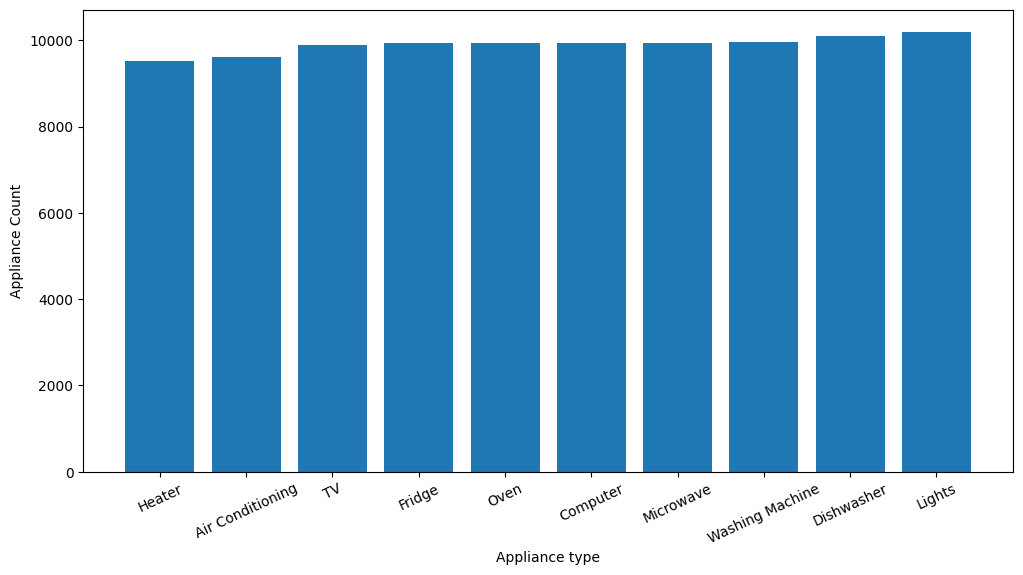

In [32]:
plt.figure(figsize=(12, 6))
plt.xlabel("Appliance type")
plt.ylabel("Appliance Count")
plt.xticks(rotation = 25)
bars = plt.bar(appliance_count.index, appliance_count.values)
plt.show()

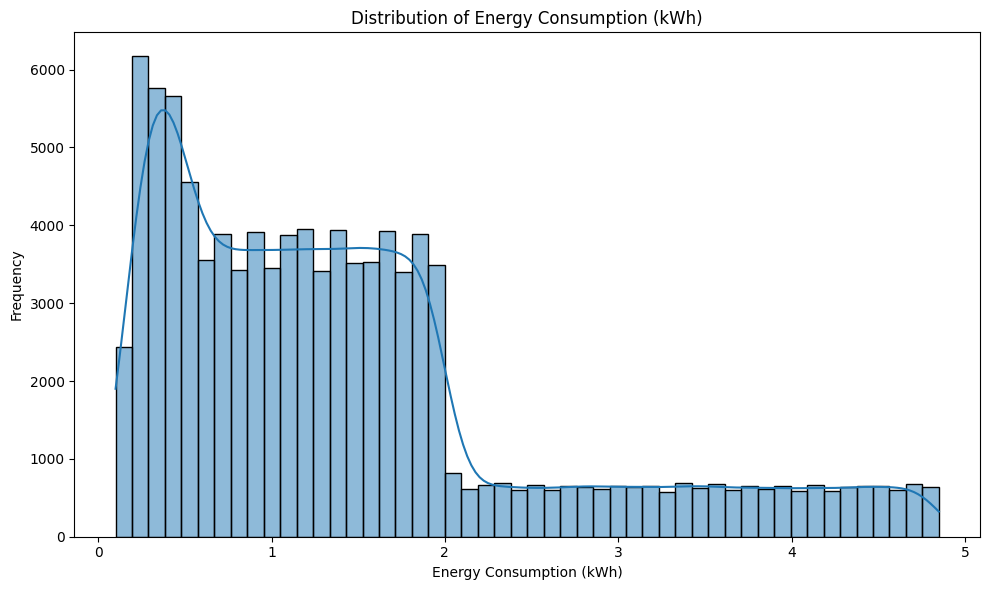

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data['Energy Consumption (kWh)'], bins=50, kde=True)
#KDE(Kernel Density Estimation)
plt.title('Distribution of Energy Consumption (kWh)')
plt.xlabel('Energy Consumption (kWh)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Total Consumption per Device

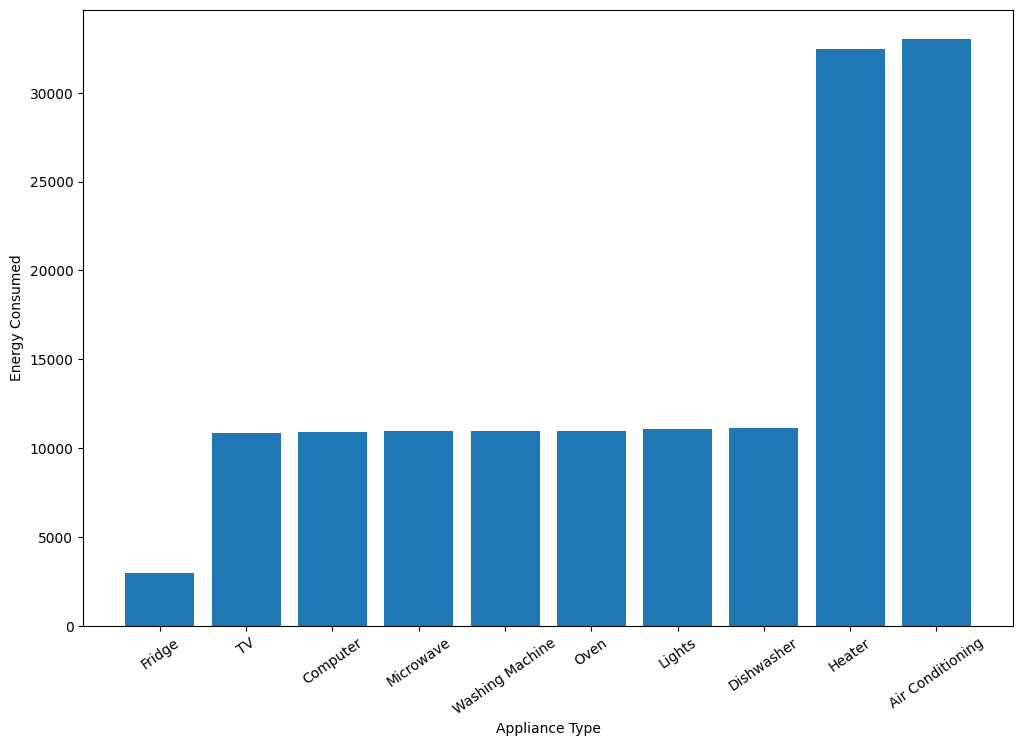

In [48]:
energy_per_device = data.groupby('Appliance Type')['Energy Consumption (kWh)'].sum().sort_values()
plt.figure(figsize=(12,8))
plt.xlabel("Appliance Type")
plt.ylabel("Energy Consumed")
plt.bar(energy_per_device.index, energy_per_device.values)
plt.xticks(rotation = 35)
plt.show()

Add Timestamp Column

In [49]:
data['timestamp'] = pd.to_datetime(
    data["Date"] + ' ' + data["Time"]
)

Drop Date and Time Column

In [51]:
data = data.drop(columns = ['Date', 'Time'])

In [52]:
data.head()

,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size,timestamp
0,94,Fridge,0.20,-1.0,Fall,2,2023-12-02 21:12:00
1,435,Oven,0.23,31.1,Summer,5,2023-08-06 20:11:00
2,466,Dishwasher,0.32,21.3,Fall,3,2023-11-21 06:39:00
3,496,Heater,3.92,-4.2,Winter,1,2023-01-21 21:56:00
4,137,Microwave,0.44,34.5,Summer,5,2023-08-26 04:31:00


Save the Processed File

In [53]:
data.to_csv('processed_data.csv', index=False)
